### hypothesis function: $$\hat{y} = h_\theta (x) = \theta x$$

## MSE: cost function $$MSE(X, h_\theta) = \frac{1}{m} \sum_{i=1}^{m}(\theta^Tx^{(i)} - y^{(i)})^2$$

### Creating features and labels

In [1]:
import numpy as np

X = 3 * np.random.rand(100, 1)
y = 3 + 2 * X + np.random.randn(100, 1)  # a affine function with noise

### The variable y equation above can be translated to: $$y = \theta_0 + \theta_1 X + noise$$
### y only has one **weight** ($\theta_1$) because X only has one **feature** ($x_1$)

## Normal Equation $$\hat{\theta} = (X^TX)^{-1}X^Ty$$

In [2]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 in every instance, to multiply the intercept  
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # normal equation
theta_best

array([[2.84881695],
       [2.12605611]])

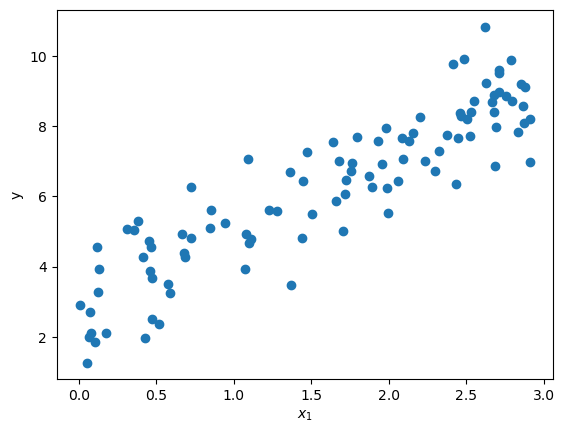

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.ylabel("y")
plt.xlabel("$x_1$")
plt.show()

In [4]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 for each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[2.84881695],
       [7.10092917]])

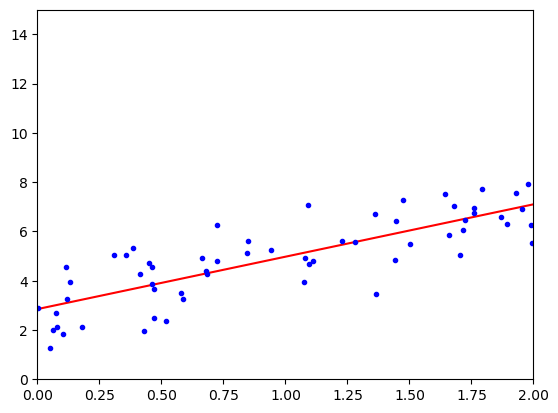

In [5]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_  # Same result as theta_best

(array([2.84881695]), array([[2.12605611]]))

In [7]:
lin_reg.predict(X_new) # Same result as 'X_new_b.dot(theta_best)'

array([[2.84881695],
       [7.10092917]])

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6) # Same funcionality as LinearRegression
theta_best_svd

array([[2.84881695],
       [2.12605611]])

### The function below calculates $\hat{\theta} = X^+y$ where $X^+$ is the pseudo-inverse of $X$:

In [9]:
np.linalg.pinv(X_b).dot(y) # Same result as normal equation...

array([[2.84881695],
       [2.12605611]])

### MSE cost function gradient vector (Batch Gradient Descent): $$\nabla_\theta \text{MSE}(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_0} \ \frac{\partial J}{\partial \theta_1} \ \vdots \ \frac{\partial J}{\partial \theta_n} \end{bmatrix} = \frac{2}{m}X^T(X\theta - y)$$ 

### Compute the cost function gradient learning: $$\theta(\text{next step}) = \theta - \eta \nabla_\theta \text{MSE}(\theta)$$
#### $\eta$ -> learning rate

In [10]:
eta = 0.001 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1) # a 'random initialization' in model parameters

for i in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) # gradient vector
    theta = theta - eta * gradients

theta # The result: trying to predict the features weights

array([[1.42019359],
       [2.83308909]])

### The learning rate above was so tiny. Now it learning rate is going TO COOK!

In [11]:
eta = 0.1 
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1) 

for i in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) 
    theta = theta - eta * gradients

theta # The result: a perfect prediction

array([[2.84881695],
       [2.12605611]])

## Stochastic Gradient Descent (SGD) 

### MSE vector gradient (SGD): $$\text{MSE}(\theta)= 2 \cdot x_{i}^T (x^{(i)}\theta - y^{(i)})$$

In [12]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t): # function to control the learning rate
    return t0 / (t + t1)

theta = np.random.randn(2, 1) # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

In [13]:
theta

array([[2.8364674 ],
       [2.12782697]])

In [14]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, eta0=0.1, penalty=None, random_state=42) # tol = 1e-3 at standard
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_ # same as theta

(array([2.83534288]), array([2.11684388]))

### Polynomial regression: is seen as a linear regression, because the machine just consider the weights ($\theta$) to make the predictions; so the $x^n$ factor don't change it's nature. *As a quadratic function: $f(x) = ax^2 + bx + c$* 
### In representation of one feature:$$\hat{y} = \theta_2 x^2 + \theta_1 x + \theta_0$$ but, it stills have more expoents capable for use. It can through as many possible its. So a universal formula is $$\hat{y} =\theta_n x^n ... \theta_2 x^2 + \theta_1 x + \theta_0$$ Polynomial regression also correlates all the features between them, so if exist two features $a$ and $b$, besides $a^2$ and $b^2$, there also will have $ab$.
#### In polynomial regression of 3 degree expoent, it also will have $a^2b$ and $b^2a$: sucessive to all the others degrees

In [15]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + 2*X + 2 + np.random.randn(m, 1)

Text(0, 0.5, '$y$')

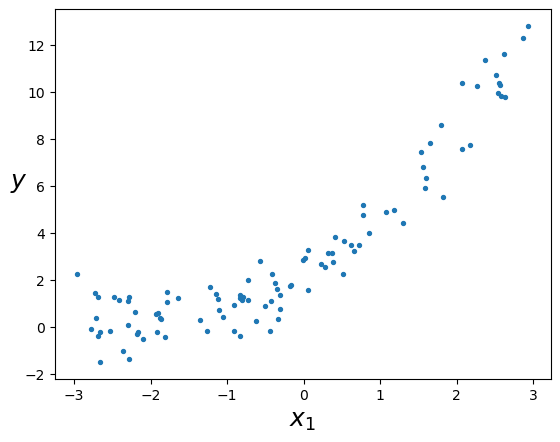

In [16]:
plt.scatter(X, y, 8)
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0], X_poly[0]

(array([-1.35289924]), array([-1.35289924,  1.83033636]))

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.20979444]), array([[1.99445451, 0.50126627]]))

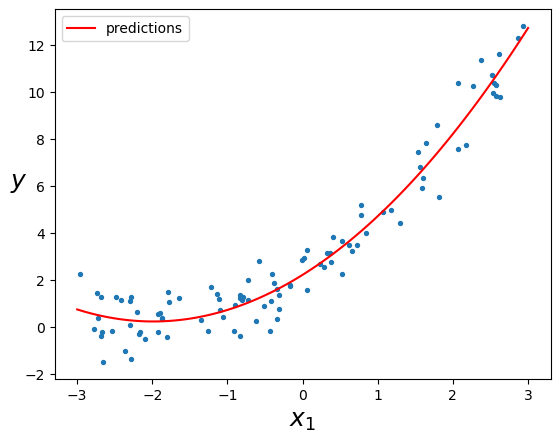

In [19]:
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.scatter(X, y, 8)
plt.plot(X_new, y_new, "r-", label="predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left")

In [22]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def ploting_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        
        X_train_pred = model.predict(X_train[:m])
        X_val_pred = model.predict(X_val)
        
        train_errors.append(mean_squared_error(y_train[:m], X_train_pred))
        val_errors.append(mean_squared_error(y_val, X_val_pred))

    plt.plot(np.sqrt(train_errors), "r+", label="train")
    plt.plot(np.sqrt(val_errors), "b-", label="validation")
    plt.legend()

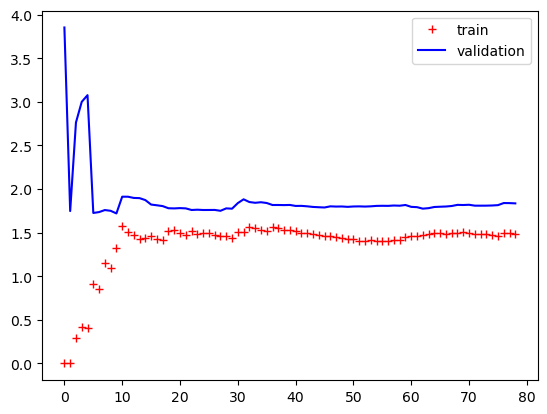

In [23]:
ploting_learning_curves(LinearRegression(), X, y)